# Libraies

In [4]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

import numpy as np

# Necessary on macoss for urllib
import os, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

#Performance measures in classification
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score, accuracy_score


In [5]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

In [6]:
X, y = mnist.data, mnist.target

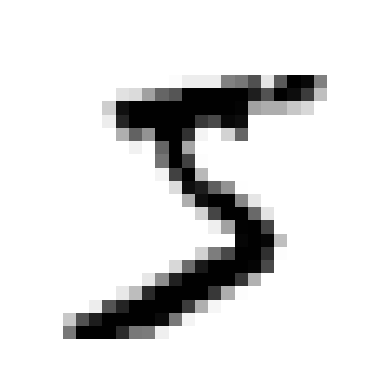

In [7]:
def plot_image(image_data):
    image_matrix = image_data.reshape(28, 28)
    plt.imshow(image_matrix, cmap='binary')
    plt.axis('off')

plot_image(X[0])

The downloaded data is alreday split strtified

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## First: Making a '5' detector --> transform the target

In [6]:
y_train_5 = y_train == '5'
y_test_5 = y_test == '5'

## Training a simple classifier
- SGD stands for stochastic gradient descent, it is not a type of classifier but the learning algorithm
- Internally it uses e.g. a SVM (support vector machine) or logistic regression (classification)

In [7]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [8]:
sgd_clf.predict([X[0]])

array([ True])

## Performance measure: accuracy

$\frac{True Positive + True Negatives}{Total Predictions}$

In [9]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

KeyboardInterrupt: 

This accurcy seems pretty good. Lets try with a Dummy classifier, which always predicts the most frequent class

In [ ]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) #Check, that no 5 is detected

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3)

array([0.90965, 0.90965, 0.90965])

The Dummy classifier performs great :D But this makes sense, since created a binary classification problem and 90 percent of the targets arr 'Not five'. So if it predicts 'No five' every time (because its dumb :)) it is 90% accurate --> Accuracy not the best measure, espeacially for unbalanced targets!

## Performance-measure: Confusion Matrix

In [ ]:
preds = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='predict')

In cross_val_predict() every sample appears in one fold. The return value is the predicted value for each sample (kind of a summary of their fold)

In [ ]:
confusion_matrix(y_true=y_train_5, y_pred=preds)

array([[53892,   687],
       [ 1891,  3530]])

## Precision
Of all positive predictions, how many were actually positive?
$\frac{True Positive}{True Positives + False Positives}$ A very defensive model (only predict true when it is super sure) can lead to precision of 100% when it makes one true prediction. Here the False negatives are not considered! --> Recall

In [ ]:
precision_score(y_train_5, preds)

0.8370879772350012

## Recall

Of all positve targets, how many were predicted correctly

$\frac{True Positive}{True Positives + False Negatives}$

In [ ]:
recall_score(y_train_5, preds)

0.6511713705958311

The F1-score is the harmonic mean and prefers a balance between prescision and recall. But for some use cases you really care about high precision. For e.g. when rating sensitive content for kids it is important to have no False Positives (high precisison). When classifiyng deseases it is bad to miss True Positives. Meaning having low False Negatives --> High Recall.

In [ ]:
f1_score(y_train_5, preds)

0.7325171197343847

The decision Function is a score, how far the prediction is from the threshold. For example the threshold of a logistic regression is at 0.5 to classifiy the results. But this is maybe not what you want! We can check the precsision and recall for different thresholds!

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=5, method='decision_function')
y_scores

array([  4411.53413566, -14087.12193543, -21565.51993633, ...,
         9394.4695853 ,  -2918.25117218,  -9160.6081938 ], shape=(60000,))

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

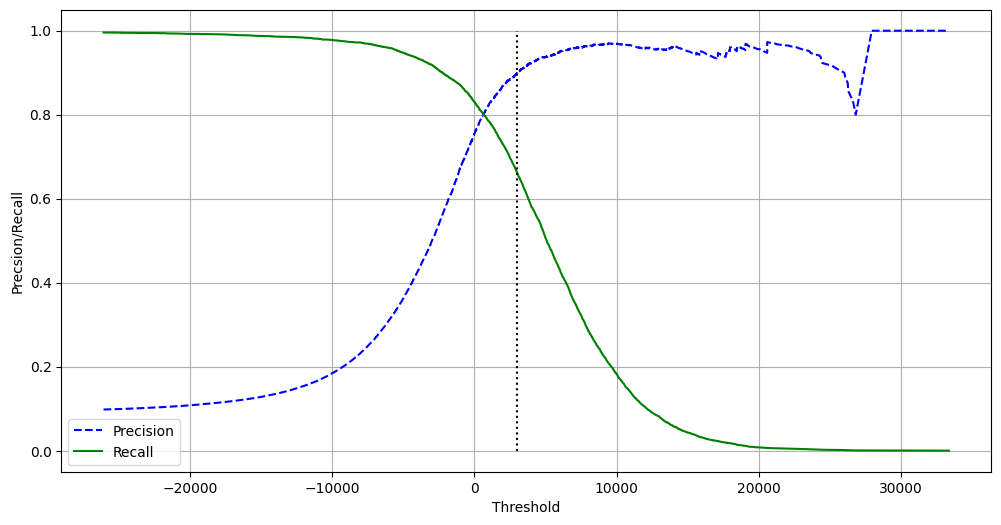

In [ ]:
fig, axes = plt.subplots(figsize=(12,6))
LOWER_BOUND = 5000
thresholds = thresholds[LOWER_BOUND:]
precisions = precisions[LOWER_BOUND:]
recalls = recalls[LOWER_BOUND:]
axes.plot(thresholds, precisions[:-1], "b--", label="Precision")
axes.plot(thresholds, recalls[:-1], "g-", label="Recall")
axes.vlines(3000, 0, 1.0, "k", "dotted")
axes.legend()
axes.set_xlabel('Threshold')
axes.set_ylabel('Precsion/Recall')
axes.grid()
plt.show()

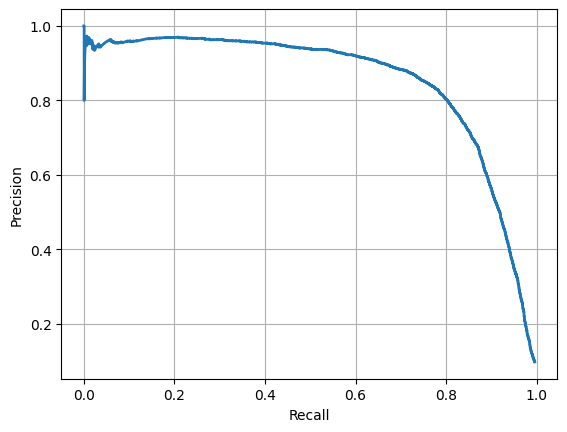

In [ ]:
plt.plot(recalls, precisions, label="Recall/precision curve", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

Precision starts to fall rapidly aat 80% recall

In [ ]:
idx_90_percent_precision = (precisions >= 0.9).argmax()
threshold_forr_90_percent_precision = thresholds[idx_90_percent_precision]

With this threshold and the scores we could make classification predictions

In [ ]:
y_pred_90_percent_precision = (y_scores >= threshold_forr_90_percent_precision)
print(precision_score(y_train_5, y_pred_90_percent_precision))
print(recall_score(y_train_5, y_pred_90_percent_precision))

0.9002016129032258
0.6589190186312488


## The ROC curve
The ROC curve plots True Positive rate (TPR or Recall) against the False Positive Rate (FPR):
- TPR: Of all positive samples, how many were correctly classified as positives
- FPR: Of all negative samplse, how many were incorrectly classified ad positives

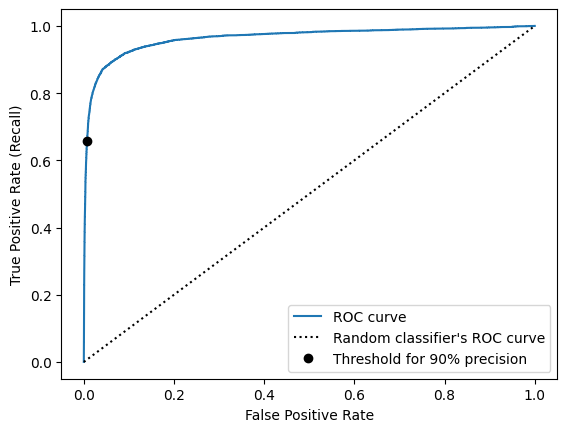

In [ ]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

threshold_forr_90_percent_precision = (thresholds <= threshold_forr_90_percent_precision).argmax()
fpr_90 = fpr[threshold_forr_90_percent_precision]
tpr_90 = tpr[threshold_forr_90_percent_precision]

plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], 'ko', label='Threshold for 90% precision')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.show()

Since the ROC curve is so similar to the precision/recall (PR)
curve, you may wonder how to decide which one to use. ***As a rule
of thumb, you should prefer the PR curve whenever the positive
class is rare or when you care more about the false positives than
the false negatives.*** Otherwise, use the ROC curve. For example,
looking at the previous ROC curve (and the ROC AUC score),
you may think that the classifier is really good. But this is mostly
because there are few positives (5s) compared to the negatives
(non-5s). In contrast, the PR curve makes it clear that the classifier
has room for improvement: the curve could really be closer to the
top-right corner

In [ ]:
print(f"The Area Under Curve score: {roc_auc_score(y_train_5, y_scores)}")

The Area Under Curve score: 0.9648211175804801


### Training a Random Forest Classifier and compare it to the SGD
Random forest do not have a score like the SGD. But they calcualte a class probability which can also be passed to the PR curve method.

In [1]:
rf_clf = RandomForestClassifier(random_state=42)

y_pred_probas = cross_val_predict(rf_clf, X_train, y_train_5, method='predict_proba')

NameError: name 'RandomForestClassifier' is not defined

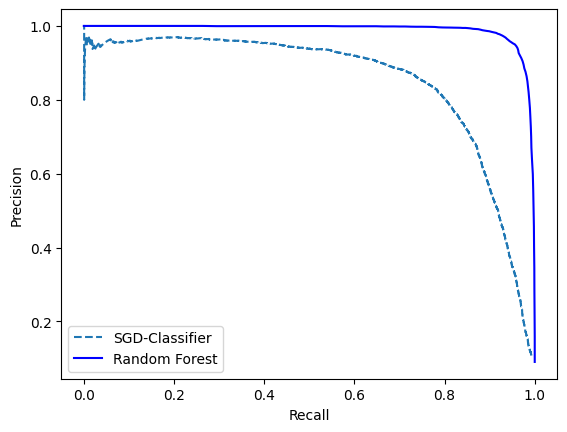

In [ ]:
y_pred_probas_positive_class = y_pred_probas[:,1]

precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_train_5, y_pred_probas_positive_class)

plt.plot(recalls, precisions, '--', label='SGD-Classifier')
plt.plot(recalls_rf, precisions_rf, 'b-', label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [ ]:
#Setting the thresold to 50%
y_train_pred_forest = (y_pred_probas_positive_class >= 0.5)
print(f"ROC AUC score: {roc_auc_score(y_train_5, y_pred_probas_positive_class)}")
print(f"Precision: {precision_score(y_train_5, y_train_pred_forest)}")
print(f"Recall: {recall_score(y_train_5, y_train_pred_forest)}")

ROC AUC score: 0.9983928750263893
Precision: 0.9898298048982981
Recall: 0.8797269876406567


# Exercise
Train a Classifier with at least 97% accuracy --> KNeighboursClassifer

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

from sklearn.metrics import classification_report

In [10]:
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of test data: {X_test.shape}")

Shape of training data: (60000, 784)
Shape of test data: (10000, 784)


In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__weights': ['uniform', 'distance'],
    'knn__n_neighbors': [3, 5, 7],
    'knn__metric': ['euclidean', 'manhattan'],
    'pca__n_components': [0.92, 0.95, 0.97]
}

grids_cv = GridSearchCV(pipeline, param_grid=param_grid, cv=5, refit=True, scoring='accuracy', n_jobs=-1)
grids_cv.fit(X_train, y_train)

KeyboardInterrupt: 

In [21]:
accuracy_score(y_test, y_pred)

0.9587

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.93      1.00      0.96      1135
           2       0.98      0.94      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.95      0.96       982
           5       0.95      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.94      0.95      0.94      1028
           8       0.98      0.91      0.94       974
           9       0.95      0.94      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

